
=== Descriptive Insights ===

Total Sales: 1489000
Average Profit: 15916.67


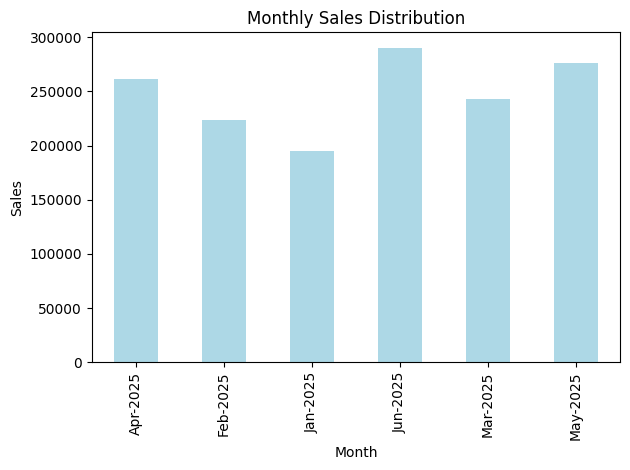


=== Diagnostic Insights ===

Correlation Matrix:
                      Sales  Advertising_Spend    Profit
Sales              1.00000           0.982360  0.988060
Advertising_Spend  0.98236           1.000000  0.989395
Profit             0.98806           0.989395  1.000000


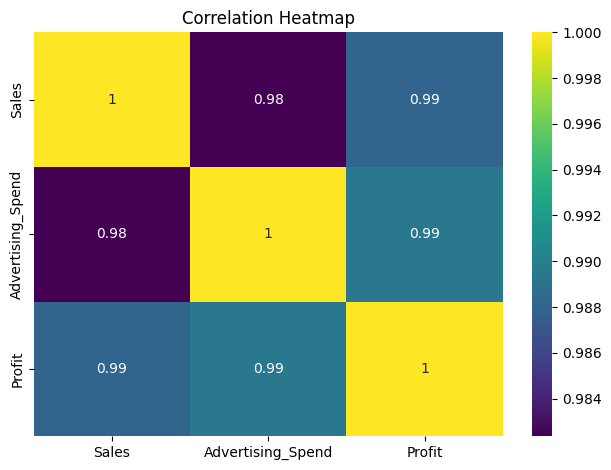


=== Predictive Model ===

Model R2 Score: 0.9879
Predicted Sales for $6000 spend: $38007.78

=== Recommendation ===

Suggested Action: Focus on cost optimization and improve marketing efficiency.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as data_split
from sklearn.linear_model import LinearRegression as LinReg
from sklearn.metrics import r2_score as r2

# -------------------- Load Dataset --------------------
df = pd.read_csv("Sales_Dataset_2025.csv")

# -------------------- 1. DESCRIPTIVE ANALYTICS --------------------
print("\n=== Descriptive Insights ===\n")

total_sales = df["Sales"].sum()
avg_profit = df["Profit"].mean()

print(f"Total Sales: {total_sales}")
print(f"Average Profit: {avg_profit:.2f}")

# Monthly Sales Visualization
monthly_summary = df.groupby("Month")["Sales"].sum()

plt.figure()
monthly_summary.plot(kind="bar", color="lightblue")
plt.title("Monthly Sales Distribution")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


# -------------------- 2. DIAGNOSTIC ANALYTICS --------------------
print("\n=== Diagnostic Insights ===\n")

# Select numeric columns only
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr = numeric_df.corr()
print("Correlation Matrix:\n", corr)

# Heatmap
plt.figure()
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# -------------------- 3. PREDICTIVE ANALYTICS --------------------
print("\n=== Predictive Model ===\n")

X = df[["Advertising_Spend"]]
y = df["Sales"]

# Train-test split
X_train, X_test, y_train, y_test = data_split(
    X, y, test_size=0.25, random_state=10
)

# Model training
model = LinReg()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model evaluation
score = r2(y_test, y_pred)
print(f"Model R2 Score: {score:.4f}")

# Future prediction (FIXED: use DataFrame with column name)
future_input = pd.DataFrame({
    "Advertising_Spend": [6000]
})

future_prediction = model.predict(future_input)
print(f"Predicted Sales for $6000 spend: ${future_prediction[0]:.2f}")


# -------------------- 4. PRESCRIPTIVE ANALYTICS --------------------
print("\n=== Recommendation ===\n")

avg_sales = df["Sales"].mean()

def recommendation(predicted, average):
    if predicted > average:
        return "Increase advertising budget to boost revenue."
    else:
        return "Focus on cost optimization and improve marketing efficiency."

advice = recommendation(future_prediction[0], avg_sales)
print("Suggested Action:", advice)